# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Jordan Sebastian Simatupang | 5054251038|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [94]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

In [95]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.
data = pd.read_csv('mushrooms.csv')
print(data.head())


  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1       

In [96]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
data.info()
data = data.replace("?", np.nan)
missing_values = data.isnull().sum()
print(missing_values)

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [97]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
nilai_unik = data.nunique()
print(nilai_unik)

class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   4
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64


<Axes: xlabel='class'>

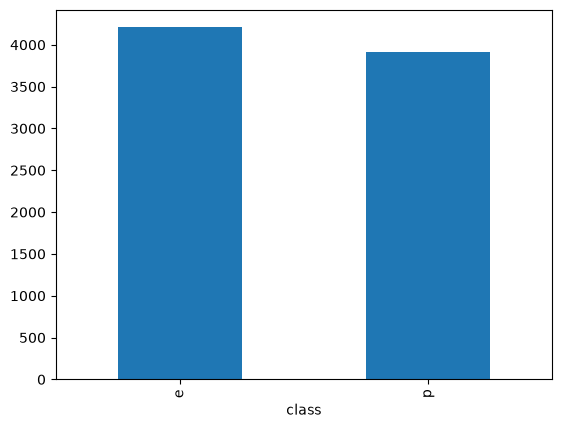

In [98]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
class_distribution = data['class'].value_counts()
class_distribution.plot(kind='bar')

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


<Axes: xlabel='stalk-root'>

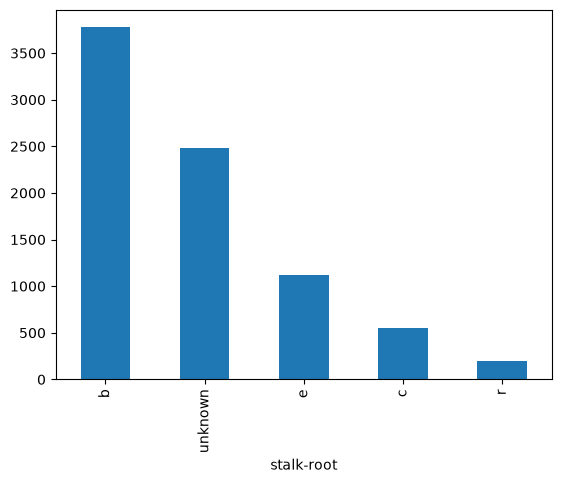

In [99]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.
data['stalk-root'] = data['stalk-root'].fillna("unknown")
print(data.isnull().sum())
distribusi_stalk_root = data['stalk-root'].value_counts()
distribusi_stalk_root.plot(kind='bar')

In [100]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.
satu_nilai_unik = data.nunique()
drop_features = satu_nilai_unik[satu_nilai_unik == 1].index.tolist()
data = data.drop(columns=drop_features)
print(f"Fitur yang di-drop karena hanya memiliki satu nilai unik: {drop_features}")
data.info()

Fitur yang di-drop karena hanya memiliki satu nilai unik: ['veil-type']
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 n

In [101]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
x = data.drop(columns=['class'])
y = data['class'].map({'e': 0, 'p': 1})
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(f"Jumlah data train: {x_train.shape[0]}, Jumlah data test: {x_test.shape[0]}")

Jumlah data train: 6499, Jumlah data test: 1625


In [102]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.
encoder_ord = OrdinalEncoder()
x_train_ord = encoder_ord.fit_transform(x_train)
x_test_ord = encoder_ord.transform(x_test)

In [103]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.
encoder_onehot = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
x_train_onehot = encoder_onehot.fit_transform(x_train)
x_test_onehot = encoder_onehot.transform(x_test)

# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [104]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
def train_categorical_nb(x_train_ord, y_train):
    model = CategoricalNB()
    model.fit(x_train_ord, y_train)
    return model

train_categorical_nb(x_train_ord, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 324.... 0., 1382.]]), array([[1248....134., 1368.]]), array([[ 38.... 542.]]), array([[1161....634., 499.]]), ...]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.33...-0.81964923]]), array([[-0.99...-0.82918638]]), array([[-4.46...-1.75582372]]), array([[-1.06...-1.83577635]]), ...]"


In [105]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
model_cnb = train_categorical_nb(x_train_ord, y_train)
prediksi_cnb = model_cnb.predict(x_test_ord)
probabilitas_cnb = model_cnb.predict_proba(x_test_ord)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [106]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
def train_bernoulli_nb(x_train_onehot, y_train):
    model = BernoulliNB()
    model.fit(x_train_onehot, y_train)
    return model

train_bernoulli_nb(x_train_onehot, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 116)","[[-2.34,-8.12,-0.97,...,-3.42,-3.73,-3.06], [-4.41,-6.44,-0.93,...,-1.39,-2.65,-8.05]]"


In [107]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
model_bnb = train_bernoulli_nb(x_train_onehot, y_train)
prediksi_bnb = model_bnb.predict(x_test_onehot)
probabilitas_bnb = model_bnb.predict_proba(x_test_onehot)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [108]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
def train_multinomial_nb(x_train_onehot, y_train):
    model = MultinomialNB()
    model.fit(x_train_onehot, y_train)
    return model

train_multinomial_nb(x_train_onehot, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 116)","[[ -5.38,-11.17, -4.02,..., -6.47, -6.77, -6.11], [ -7.46, -9.49, -3.97,..., -4.43, -5.69,-11.1 ]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,116


In [109]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
model_mnb = train_multinomial_nb(x_train_onehot, y_train)
prediksi_mnb = model_mnb.predict(x_test_onehot)
probabilitas_mnb = model_mnb.predict_proba(x_test_onehot)[:, 1]

# 4. Evaluasi Model

In [110]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
evaluasi_cnb = {
    'Model': 'CategoricalNB',
    'Accuracy': accuracy_score(y_test, prediksi_cnb),
    'Precision': precision_score(y_test, prediksi_cnb),
    'Recall': recall_score(y_test, prediksi_cnb),
    'F1-Score': f1_score(y_test, prediksi_cnb)
}
evaluasi_bnb = {
    'Model': 'BernoulliNB',
    'Accuracy': accuracy_score(y_test, prediksi_bnb),
    'Precision': precision_score(y_test, prediksi_bnb),
    'Recall': recall_score(y_test, prediksi_bnb),
    'F1-Score': f1_score(y_test, prediksi_bnb)
}
evaluasi_mnb = {
    'Model': 'MultinomialNB',
    'Accuracy': accuracy_score(y_test, prediksi_mnb),
    'Precision': precision_score(y_test, prediksi_mnb),
    'Recall': recall_score(y_test, prediksi_mnb),
    'F1-Score': f1_score(y_test, prediksi_mnb)
}
tabel_evaluasi = pd.DataFrame([evaluasi_cnb, evaluasi_bnb, evaluasi_mnb])
print(tabel_evaluasi)

           Model  Accuracy  Precision    Recall  F1-Score
0  CategoricalNB  0.945846   0.990127  0.896552  0.941019
1    BernoulliNB  0.932923   0.981429  0.877395  0.926500
2  MultinomialNB  0.945846   0.990127  0.896552  0.941019


Text(0.5, 1.0, 'Confusion Matrix - MultinomialNB')

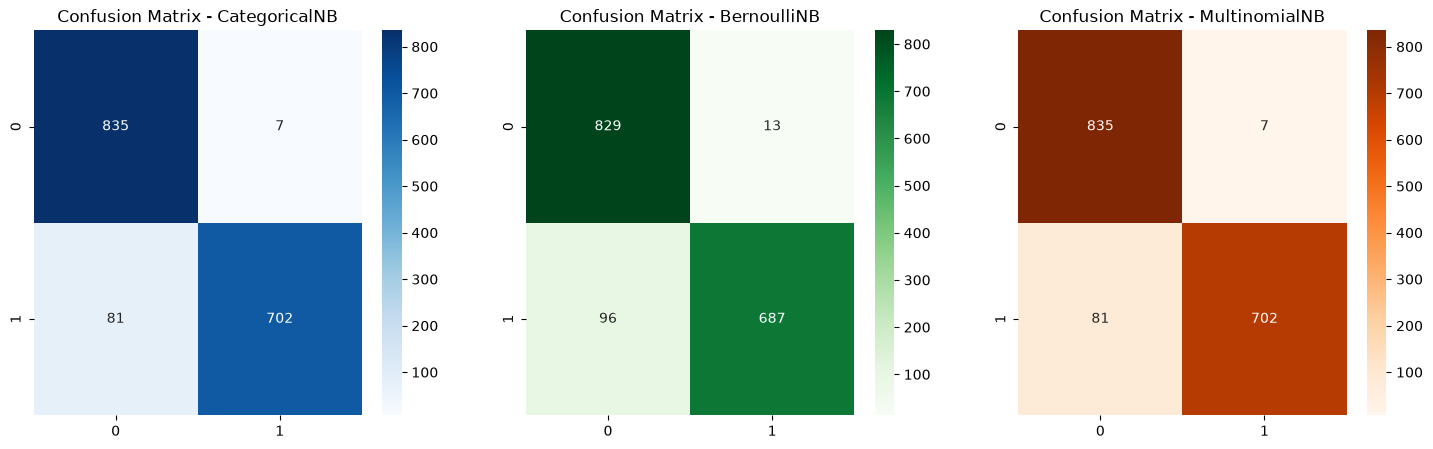

In [111]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
CM_cnb = confusion_matrix(y_test, prediksi_cnb)
CM_bnb = confusion_matrix(y_test, prediksi_bnb)
CM_mnb = confusion_matrix(y_test, prediksi_mnb)
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.heatmap(CM_cnb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CategoricalNB')
plt.subplot(1, 3, 2)
sns.heatmap(CM_bnb, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - BernoulliNB')
plt.subplot(1, 3, 3)
sns.heatmap(CM_mnb, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - MultinomialNB')

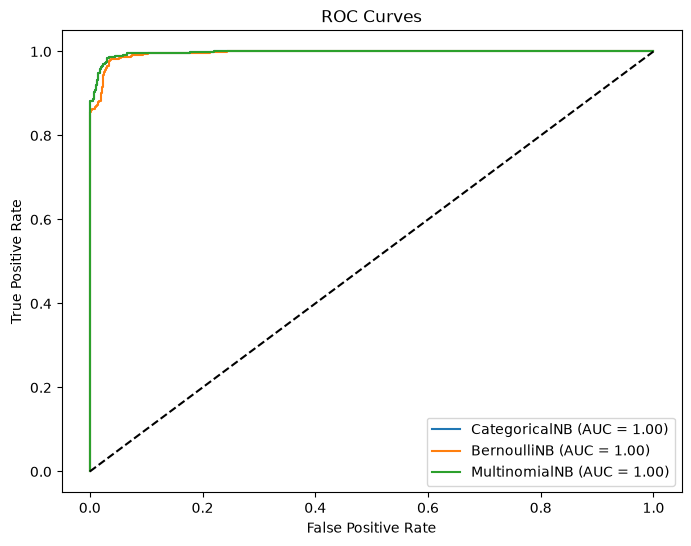

In [112]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
ROC_cnb = roc_curve(y_test, probabilitas_cnb)
ROC_bnb = roc_curve(y_test, probabilitas_bnb)
ROC_mnb = roc_curve(y_test, probabilitas_mnb)
plt.figure(figsize=(8, 6))
plt.plot(ROC_cnb[0], ROC_cnb[1], label=f'CategoricalNB (AUC = {roc_auc_score(y_test, probabilitas_cnb):.2f})')
plt.plot(ROC_bnb[0], ROC_bnb[1], label=f'BernoulliNB (AUC = {roc_auc_score(y_test, probabilitas_bnb):.2f})')
plt.plot(ROC_mnb[0], ROC_mnb[1], label=f'MultinomialNB (AUC = {roc_auc_score(y_test, probabilitas_mnb):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Hasil evaluasi menunjukkan bahwa CategoricalNB dan MultinomialNB memiliki performa yang sama. Keduanya memperoleh accuracy 94,58%, precision 99,01%, recall 89,66%, dan F1-score 94,10%. BernoulliNB memperoleh hasil sedikit lebih rendah, yaitu accuracy 93,29%, precision 98,14%, recall 87,74%, dan F1-score 92,65%.

Hasil confusion matrix juga mendukung perbandingan tersebut. CategoricalNB dan MultinomialNB menghasilkan 7 false positive dan 81 false negative. BernoulliNB menghasilkan 13 false positive dan 96 false negative. Karena kelas 1 adalah jamur beracun, false negative perlu diperhatikan. Kesalahan ini berarti jamur beracun diprediksi sebagai jamur yang dapat dimakan. Oleh karena itu, CategoricalNB dan MultinomialNB lebih baik dalam mengurangi kesalahan tersebut.

Perbedaan hasil dipengaruhi oleh bentuk data yang digunakan. CategoricalNB menggunakan OrdinalEncoder, sehingga setiap kategori diubah menjadi kode angka. Cara ini sesuai untuk data kategorikal karena model tetap membedakan setiap kategori sebagai nilai yang berbeda.

BernoulliNB dan MultinomialNB menggunakan OneHotEncoder. Setiap kategori diubah menjadi nilai 0 atau 1. Representasi ini cocok untuk BernoulliNB, tetapi pada eksperimen ini menghasilkan lebih banyak kesalahan. MultinomialNB biasanya digunakan untuk data jumlah atau frekuensi, tetapi tetap dapat memproses nilai 0 dan 1. Pada dataset ini, hasil MultinomialNB sama dengan CategoricalNB.

ROC curve menampilkan AUC 1,00 untuk ketiga model setelah dibulatkan. Ini menunjukkan bahwa ketiganya dapat membedakan kelas edible dan poisonous dengan sangat baik pada data uji. Namun, hasil ini tetap perlu dilihat bersama recall dan confusion matrix.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

##### Kesimpulan

1. CategoricalNB dan MultinomialNB memberikan hasil terbaik dengan accuracy 94,58% dan F1-score 94,10%.
2. BernoulliNB memiliki hasil sedikit lebih rendah, dengan accuracy 93,29% dan F1-score 92,65%.
3. CategoricalNB dan MultinomialNB menghasilkan 81 false negative, sedangkan BernoulliNB menghasilkan 96. Jadi, CategoricalNB dan MultinomialNB lebih baik dalam mengenali jamur beracun.
4. Ketiga model memiliki AUC 1,00 setelah pembulatan. Artinya, ketiganya mampu membedakan jamur edible dan poisonous dengan sangat baik pada data uji.

##### Saran

1. Gunakan validasi silang agar hasil tidak hanya bergantung pada satu pembagian data.
2. Coba atur nilai `alpha` untuk mencari parameter model yang lebih baik.
3. Perhatikan recall kelas jamur beracun karena false negative memiliki risiko yang lebih besar.
4. Bandingkan hasilnya dengan Logistic Regression, Decision Tree, Random Forest, atau SVM.
5. Analisis fitur untuk mengetahui ciri jamur yang paling berpengaruh terhadap hasil klasifikasi.